In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:
import pandas as pd
import numpy as np
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# Importar funciones personalizadas
from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error, resumen_final_modelos
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)

## Lectura de fichero y adaptación de los tipos


In [4]:
df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())


Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   idSecuencia       625800 non-null  datetime64[ns]
 1   producto          625800 non-null  int64         
 2   udsVenta          625800 non-null  int64         
 3   bolPromocion      625800 non-null  int64         
 4   bolOpen           625800 non-null  int64         
 5   bolHoliday        625800 non-null  int64         
 6   udsStock          625800 non-null  int64         
 7   rotura_stock      625800 non-null  bool          
 8   dia_semana        625800 non-null  int64         
 9   mes               625800 non-null  int64         
 10  semana            625800 non-null  int64         
 11  lag_ventas_1      625800 non-null  float64       
 12  lag_ventas_2      625800 non-null  float64       
 13  lag_ventas_3

# Random Forests (RF)

El algoritmo **Random Forest** (RF) es un método de **aprendizaje de conjunto (ensemble)** que construye y combina resultados de múltiples árboles de decisión.

1. **Generación de Múltiples Árboles (Bagging):** Cada árbol se entrena sobre un subconjunto de datos diferente utilizando la técnica de **Bagging** (Bootstrap Aggregating). Esto implica tomar **muestras repetidas con reemplazo** del conjunto de entrenamiento original (muestreo *bootstrap*).

2. **Decorrelación (Aleatoriedad de Características):** Para garantizar que los árboles no estén correlacionados (sean *decorrelacionados*), en cada paso de división (*split*) del árbol, el algoritmo considera solo un **subconjunto aleatorio de las características** disponibles para encontrar la mejor división. Esta doble aleatoriedad (en datos y en características) ayuda a reducir la **varianza**.

3. **Obtención del Resultado Final:** Una vez entrenados todos los árboles del "bosque" ($M$ árboles), el resultado final se obtiene:
    *   Para problemas de **Regresión** (predicción de series temporales), se obtiene **promediando** las salidas de todos los árboles.
    *   Para problemas de **Clasificación**, se obtiene por **votación mayoritaria**.

Este método es popular ya que es difícil que sufra de sobreajuste (*overfitting*) y aumenta la solidez de la predicción.




# Preparación de datos

In [5]:
# Eliminar días que la tienda está cerrada bolOpne == 0 ya que en modelos tipo Random Forest no aportan nada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()

In [6]:
# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'semana',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

# ============================================================================
# LISTA PARA ALMACENAR TODAS LAS MÉTRICAS
# ============================================================================
todas_metricas = []  # ← Lista global para todas las métricas

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE RANDOM FOREST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE RANDOM FOREST


# Random Forest global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de Random Forest para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:
# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 1: RANDOM FOREST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")



📍 MODELO 1: RANDOM FOREST GLOBAL

✅ X_train shape: (521202, 17)
✅ X_test shape: (23244, 17)

✅ X_tr shape: (416962, 17)
✅ X_val shape: (104240, 17)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:
print("\n🔍 Búsqueda de hiperparámetros con Optuna...")

# =====================================================
#  FUNCION OBJETIVO OPTUNA PARA RANDOM FOREST
# =====================================================

def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 4, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    mse = mean_squared_error(y_val, preds)
    return mse

tscv = TimeSeriesSplit(n_splits=2)

# =====================================================
# EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para Random Forest...")
start_time = time.perf_counter()

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=5, n_jobs=-1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🌲 Mejores hiperparámetros RANDOM FOREST:")
print(study_rf.best_params)


[I 2025-12-04 11:34:37,720] A new study created in memory with name: no-name-8771b102-e50a-4065-8ac5-68c56f1d811a



🔍 Búsqueda de hiperparámetros con Optuna...

🔍 Iniciando optimización de hiperparámetros con Optuna para Random Forest...


[I 2025-12-04 11:42:44,828] Trial 4 finished with value: 3.9301464470071172 and parameters: {'n_estimators': 828, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 4 with value: 3.9301464470071172.
[I 2025-12-04 11:45:17,171] Trial 1 finished with value: 3.826605146366972 and parameters: {'n_estimators': 457, 'max_depth': 17, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 3.826605146366972.
[I 2025-12-04 11:47:27,643] Trial 3 finished with value: 3.8327950901148604 and parameters: {'n_estimators': 576, 'max_depth': 21, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 3.826605146366972.
[I 2025-12-04 11:48:48,179] Trial 2 finished with value: 3.8140344040668075 and parameters: {'n_estimators': 817, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features

✅ Optuna completado en 895.89 segundos

🌲 Mejores hiperparámetros RANDOM FOREST:
{'n_estimators': 817, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}


In [9]:
print("\nEntrenando modelo RANDOM FOREST con mejores hiperparámetros en todo el conjunto de entrenamiento...")
best_rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)


Entrenando modelo RANDOM FOREST con mejores hiperparámetros en todo el conjunto de entrenamiento...


,n_estimators,817
,criterion,'squared_error'
,max_depth,15
,min_samples_split,9
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_rf.predict(X_test)

# Calcular métricas y GUARDAR
metricas_test_global = calcular_metricas(
    y_test, y_test_pred,
    algoritmo='RF', ndetalle='Global', cluster=None, producto=None)

# todas_metricas.append(metricas_train_global)
todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='RF', ndetalle='Global', cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='RF',
            ndetalle='Global', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)       


📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF   Global    None     None 1.5945 2.3899 0.2546     48.73     143.89 0.7324    97.65

🏆 Mejor modelo: RF (RMSE: 2.3899)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF   Global      3.0     314.0 0.3962  0.4005  0.0000       NaN     200.00    NaN      NaN
       RF   Global      3.0     257.0 0.9360  1.2047 -0.0938     66.93     181.62 0.8197   187.19
       RF   Global      3.0       NaN 1.1130  1.7053  0.0256     53.93     168.26 0.7652   137.05
       RF   Global      0.0     413.0 1.7291  2.1666  0.0302     33.85     102.18 0.7585    83.25
       RF   Global      NaN       NaN 1.5945  2.3899  0.2546     48.73     143.89 0.7324    97.65
       RF   Global      0.0       NaN 1.8136  2.5485  0.1177     39.18     125.17 0.7326    93.93
       RF   Gl

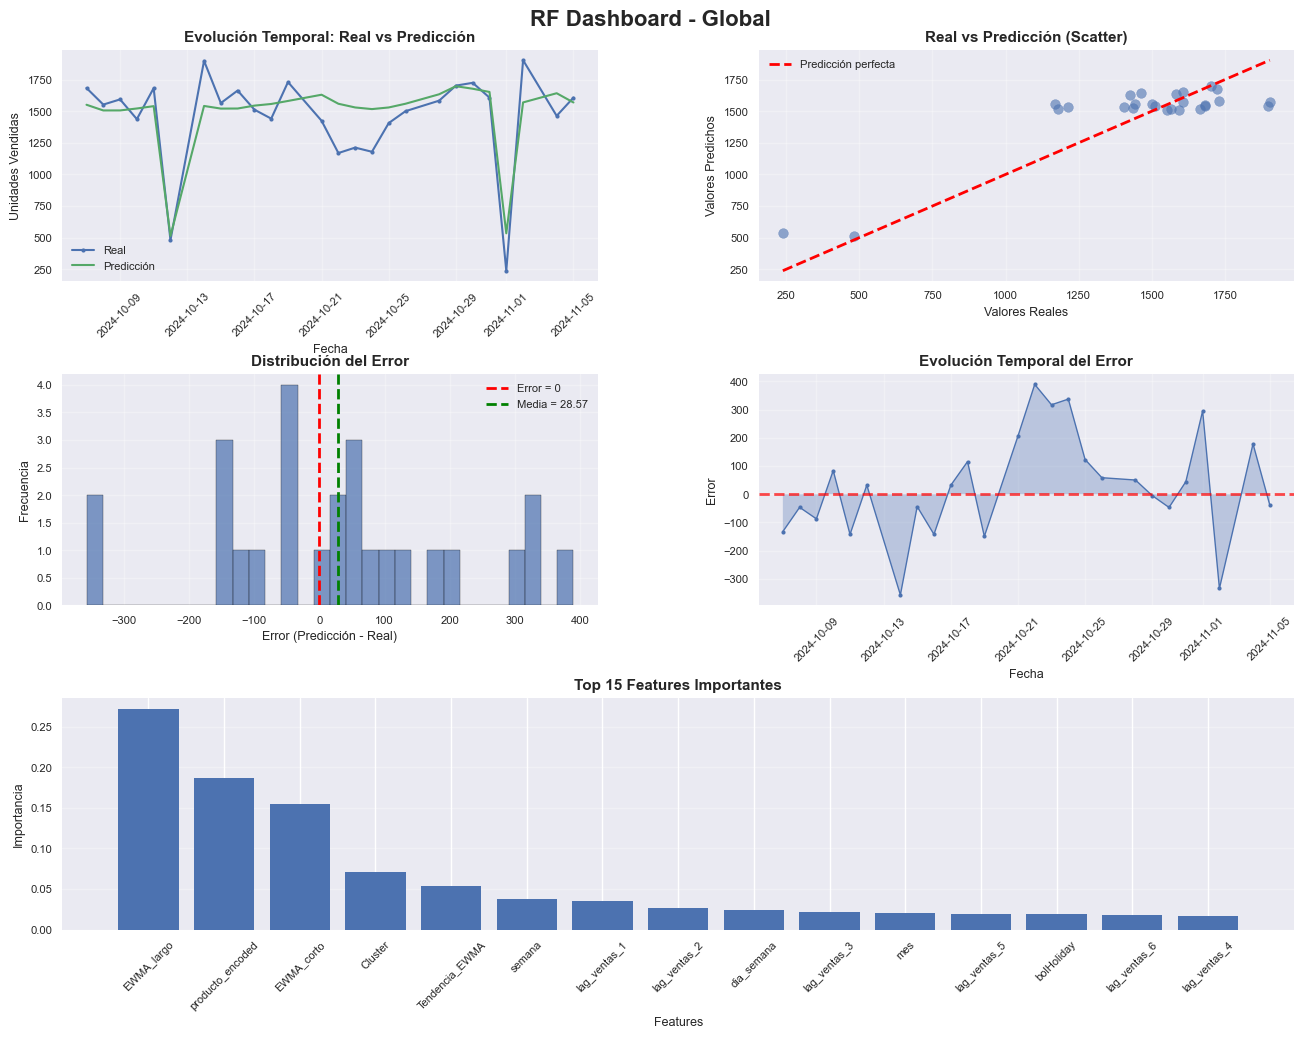

In [11]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_rf,
        feature_names=FEATURES,
        titulo_principal=f'RF Dashboard - Global'
        )


# Random Forest por Cluster


📍 MODELO 2: RANDOM FOREST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        0     None 1.8134 2.5505 0.1163     39.26     125.21 0.7332    93.91

🏆 Mejor modelo: RF (RMSE: 2.5505)


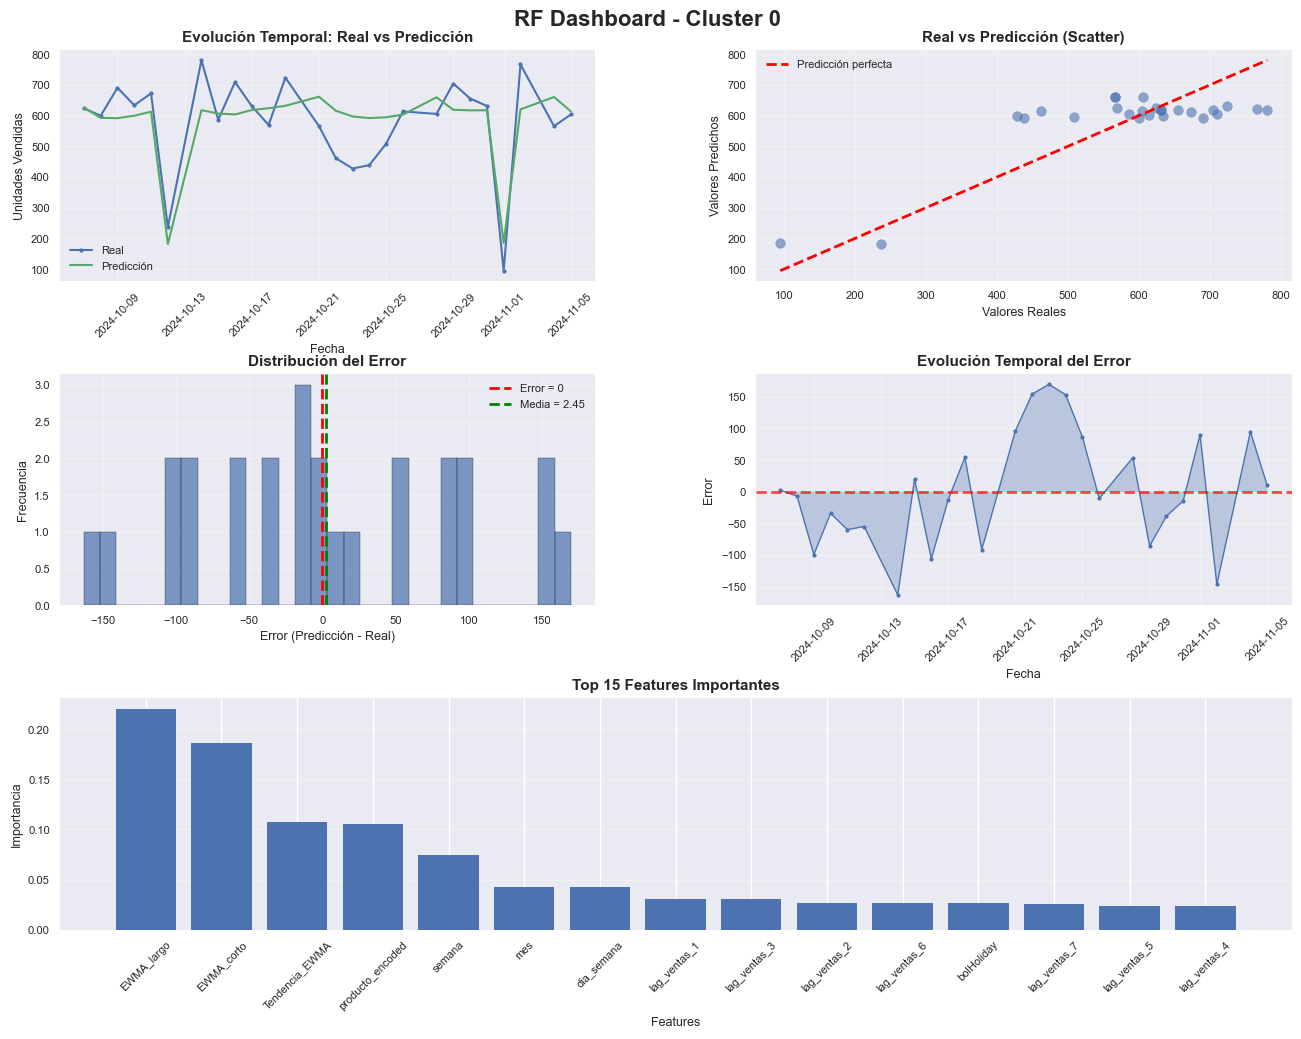


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        1     None 2.8143 3.5968 0.1395     55.81      98.28 0.7189    73.81

🏆 Mejor modelo: RF (RMSE: 3.5968)


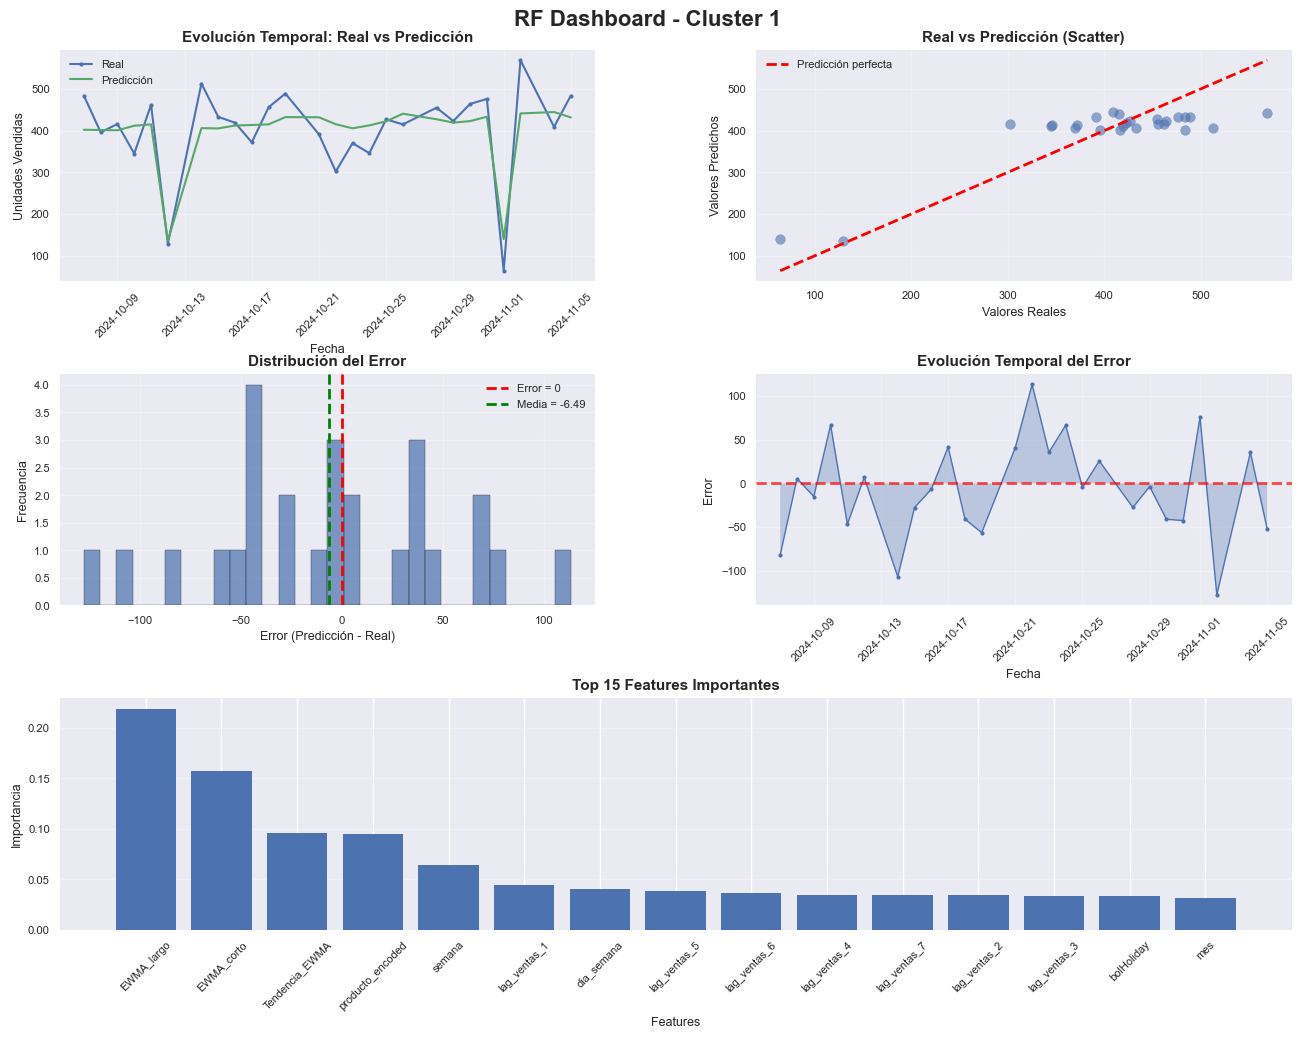


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE    R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        2     None 3.7172 5.1071 0.194     75.84      80.56 0.7102    64.73

🏆 Mejor modelo: RF (RMSE: 5.1071)


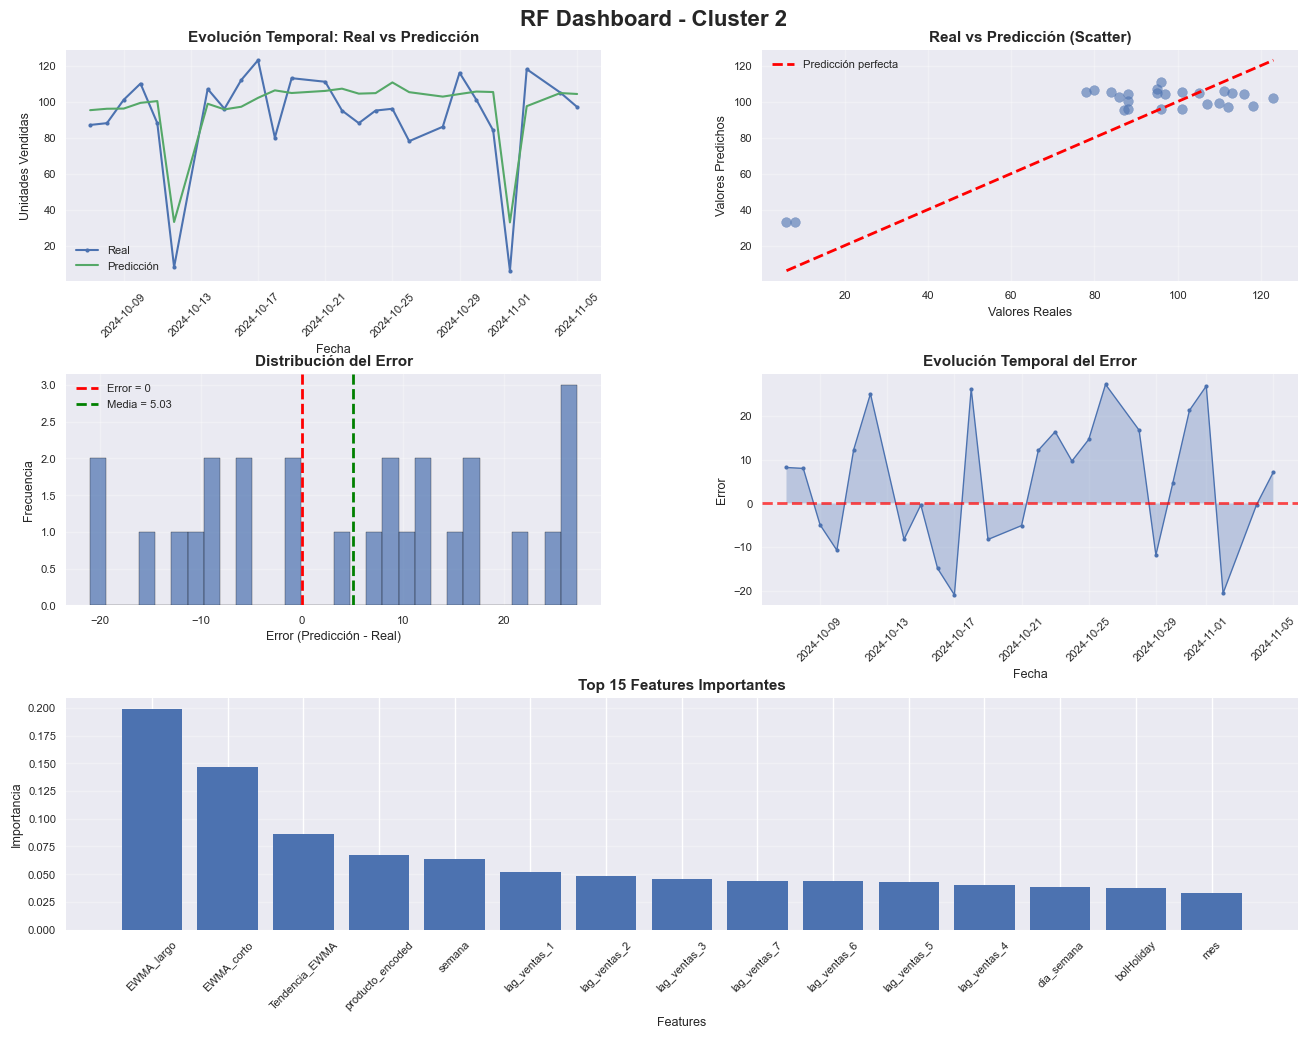


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        3     None 1.1064 1.722 0.0064     54.03     168.32 0.7727   136.24

🏆 Mejor modelo: RF (RMSE: 1.7220)


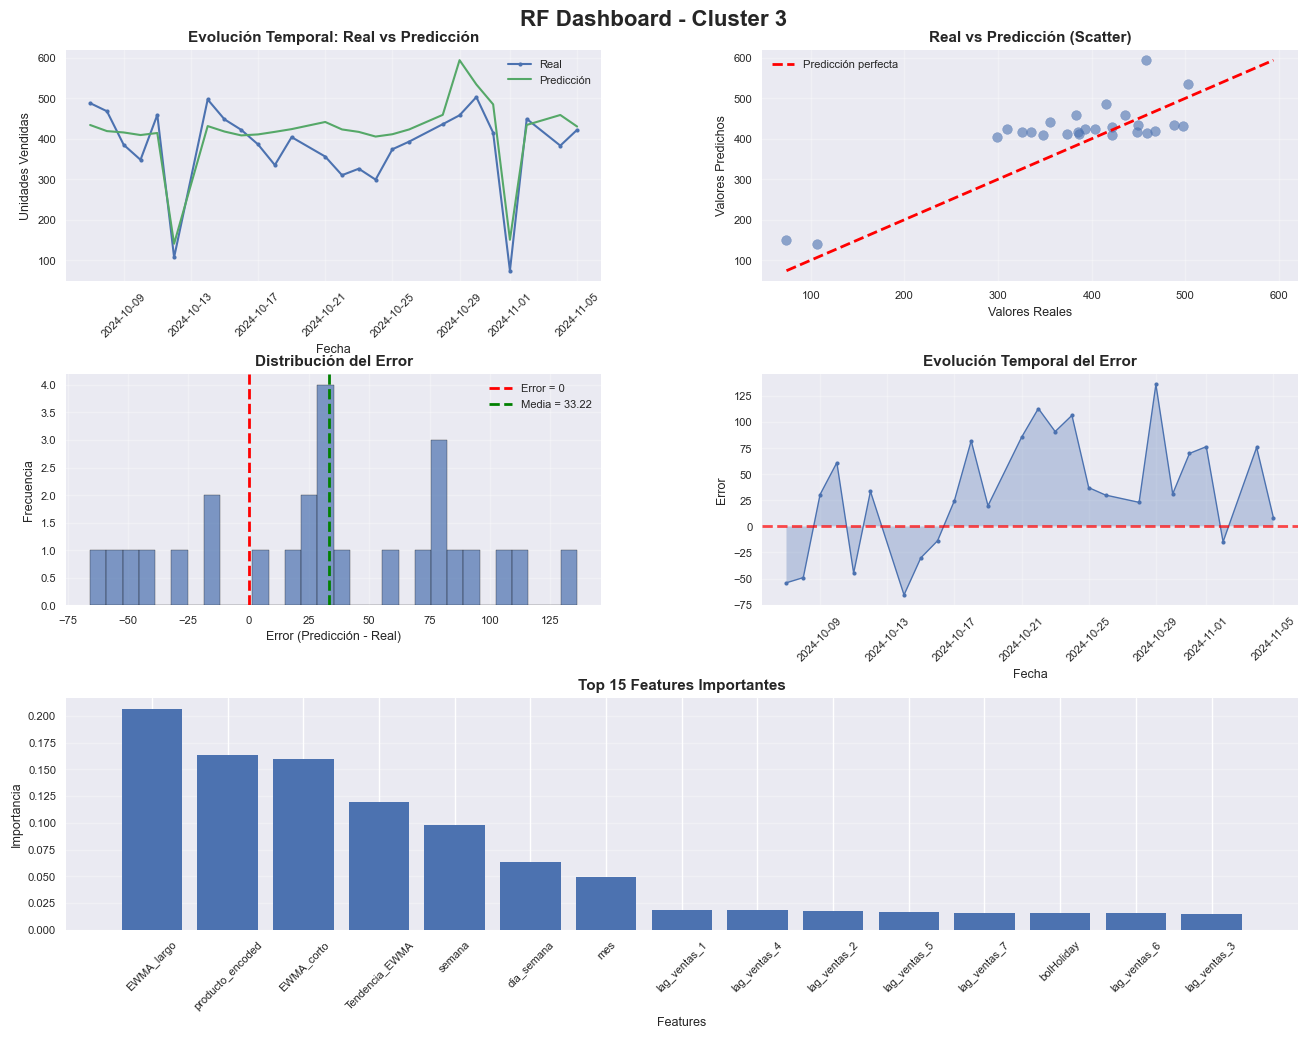

In [12]:
# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 2: RANDOM FOREST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
    
    # Entrenar
    rf_cluster = RandomForestRegressor(
        **study_rf.best_params,
        random_state=42,
        n_jobs=-1
)
    
    rf_cluster.fit(X_train_c, y_train_c)
    y_pred_c = rf_cluster.predict(X_test_c)
    
    # modelos_cluster[cluster] = rf_cluster
    
    # Calcular métricas y GUARDAR
    metricas_cluster = calcular_metricas(
        y_test_c, y_pred_c,
        algoritmo="RF", ndetalle='Cluster', cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='RF',
            ndetalle='Cluster', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=rf_cluster,
        feature_names=FEATURES,
        titulo_principal=f'RF Dashboard - Cluster {cluster}'
        )
  


# Random Forest por top 2 productos de ventas por cluster


📍 MODELO 3: RANDOM FOREST POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        0       413 1.7416 2.1941 0.0054     33.69      103.6 0.7681    83.85

🏆 Mejor modelo: RF (RMSE: 2.1941)


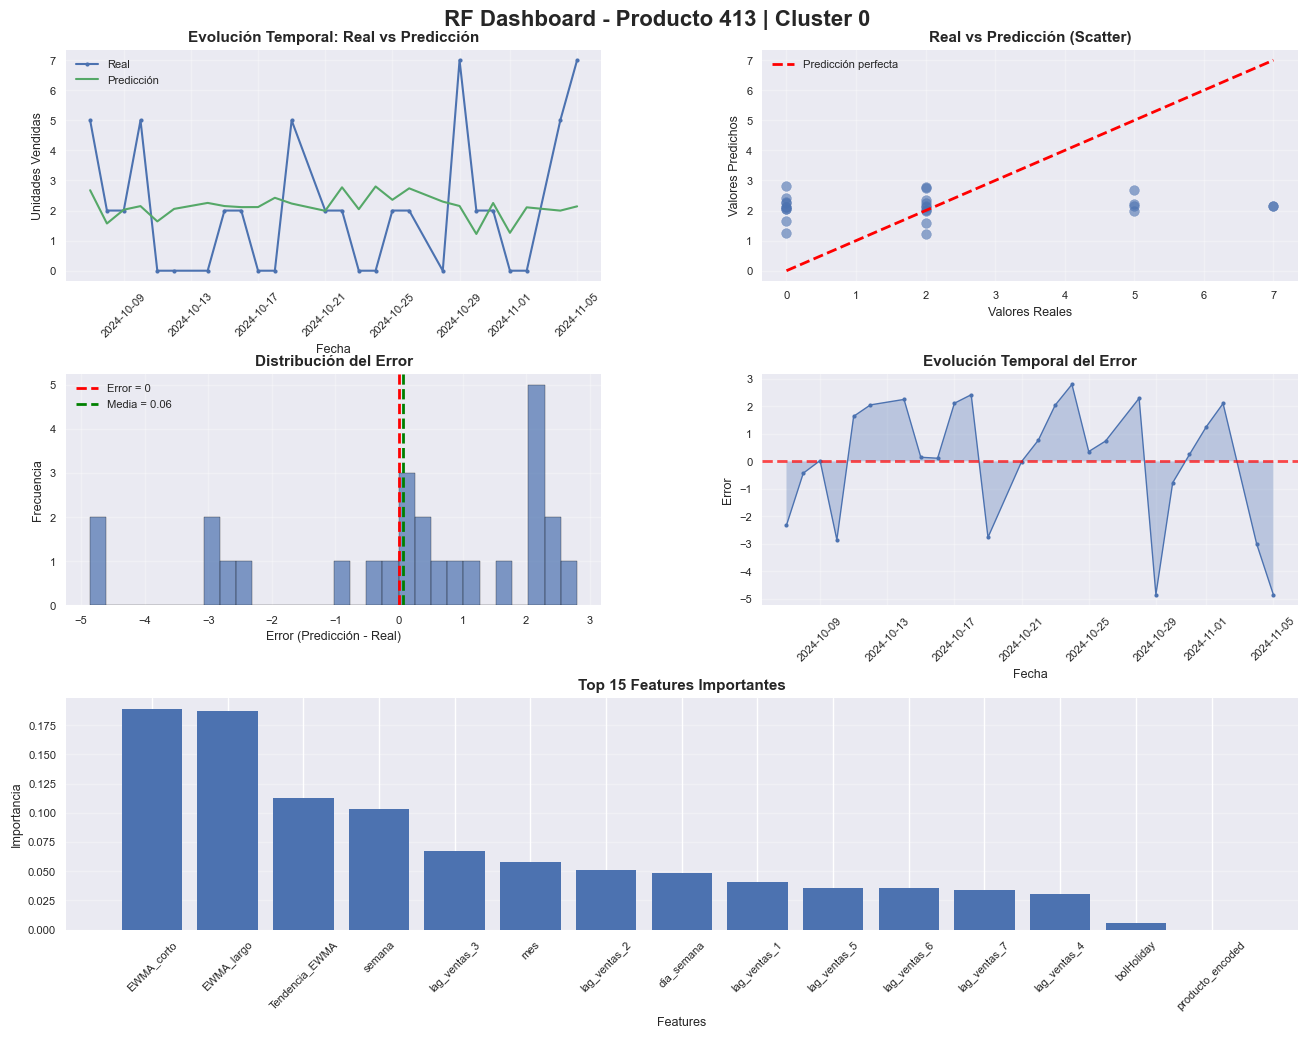


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        0       294 2.523 3.1726 -0.2619     53.87     136.03 0.7309   136.66

🏆 Mejor modelo: RF (RMSE: 3.1726)


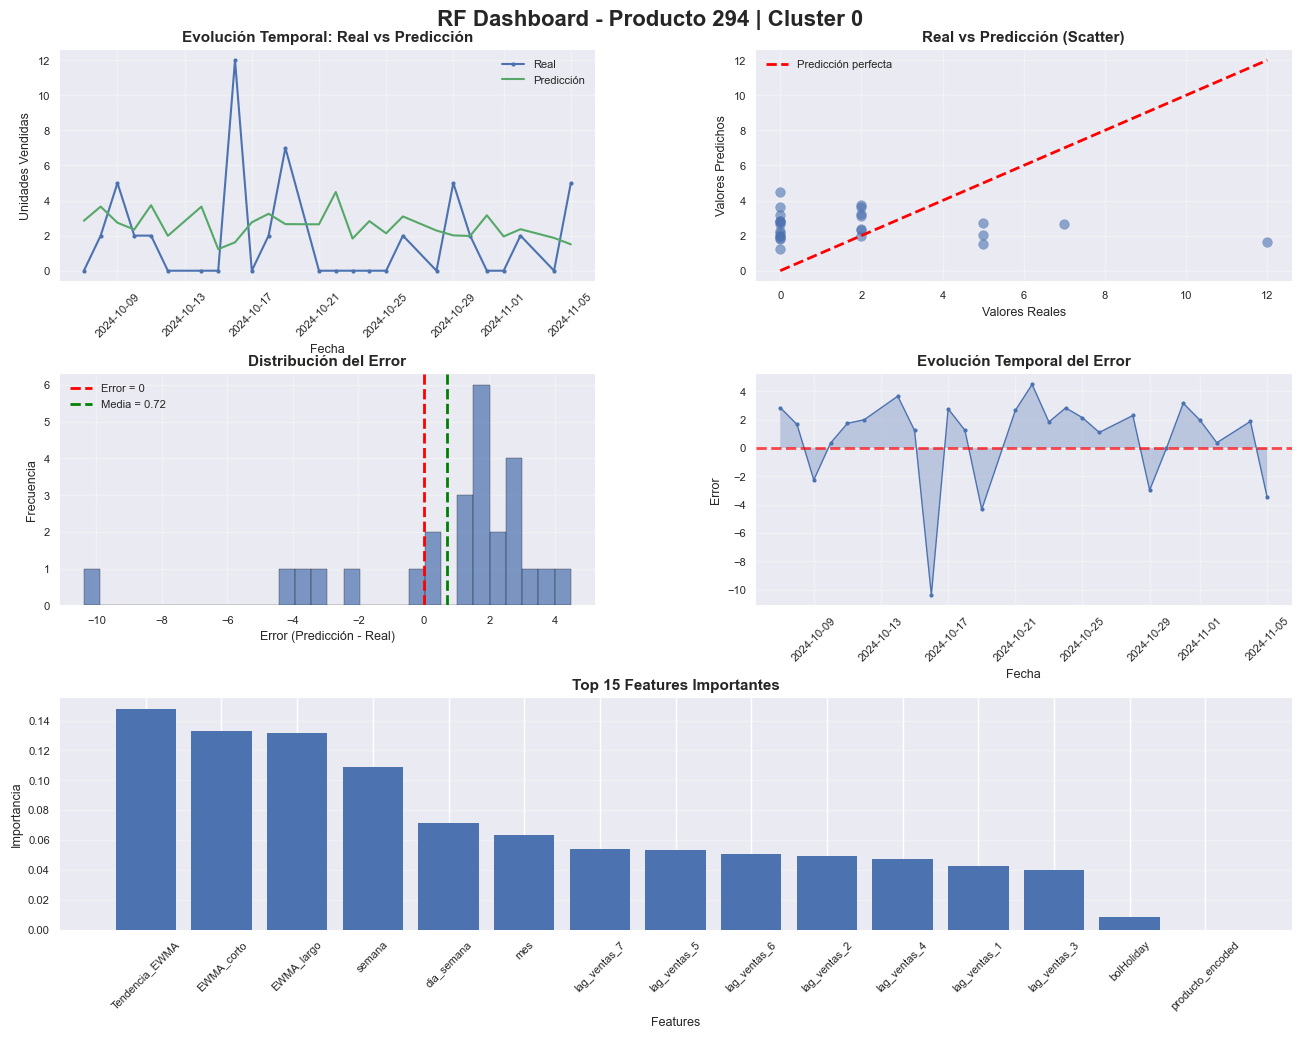


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        1       144 4.2375 5.3234 -0.1032     82.19      86.47 0.7957    74.95

🏆 Mejor modelo: RF (RMSE: 5.3234)


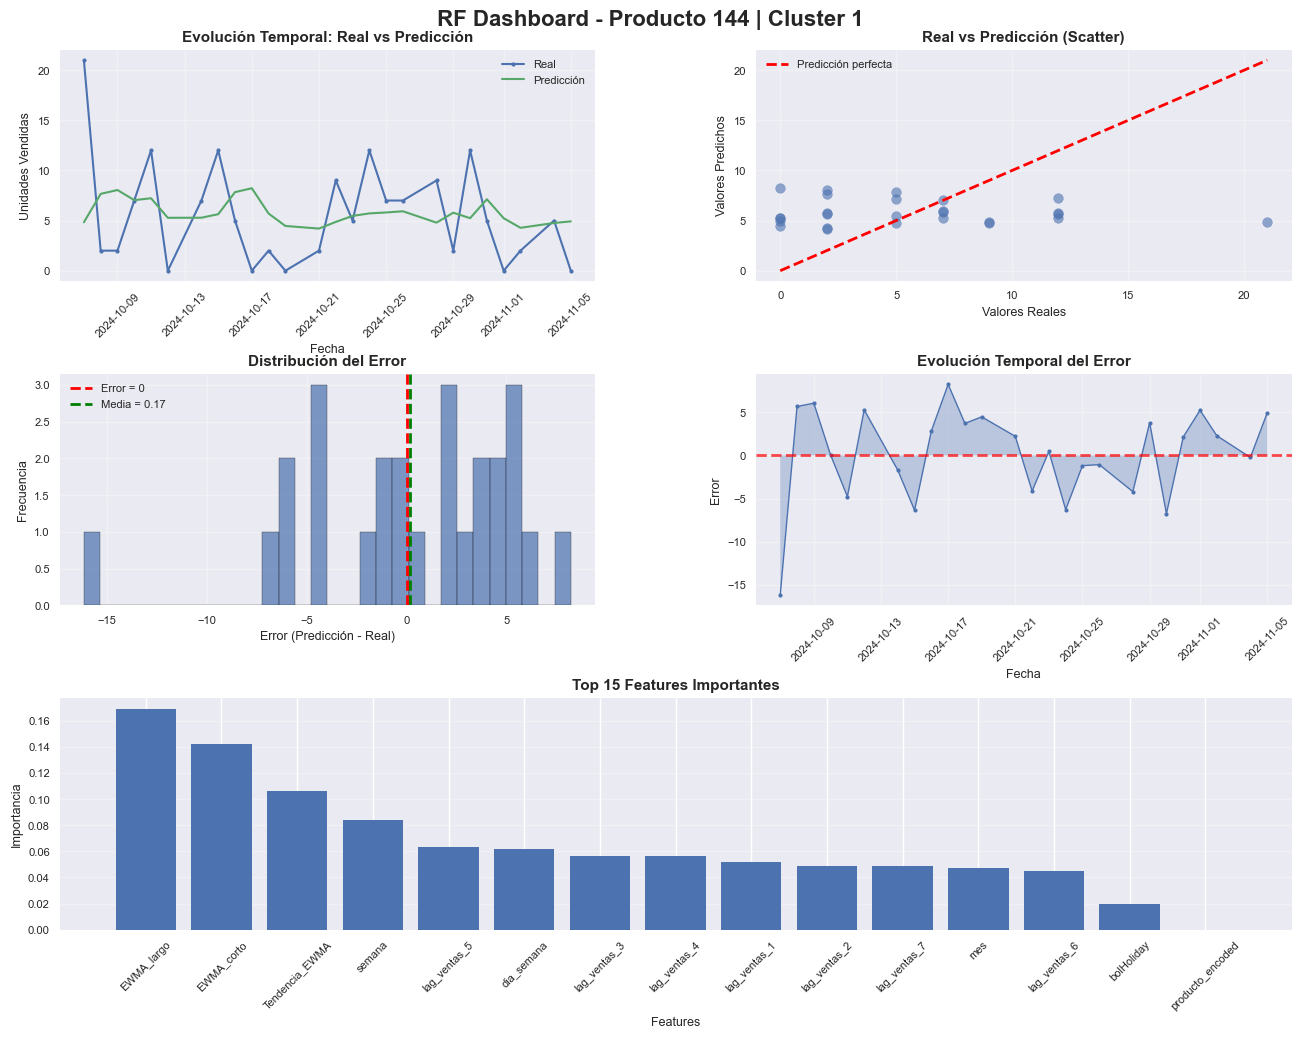


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        1        41 3.6836 4.7111 -0.0885     61.63      68.04 0.8042    55.68

🏆 Mejor modelo: RF (RMSE: 4.7111)


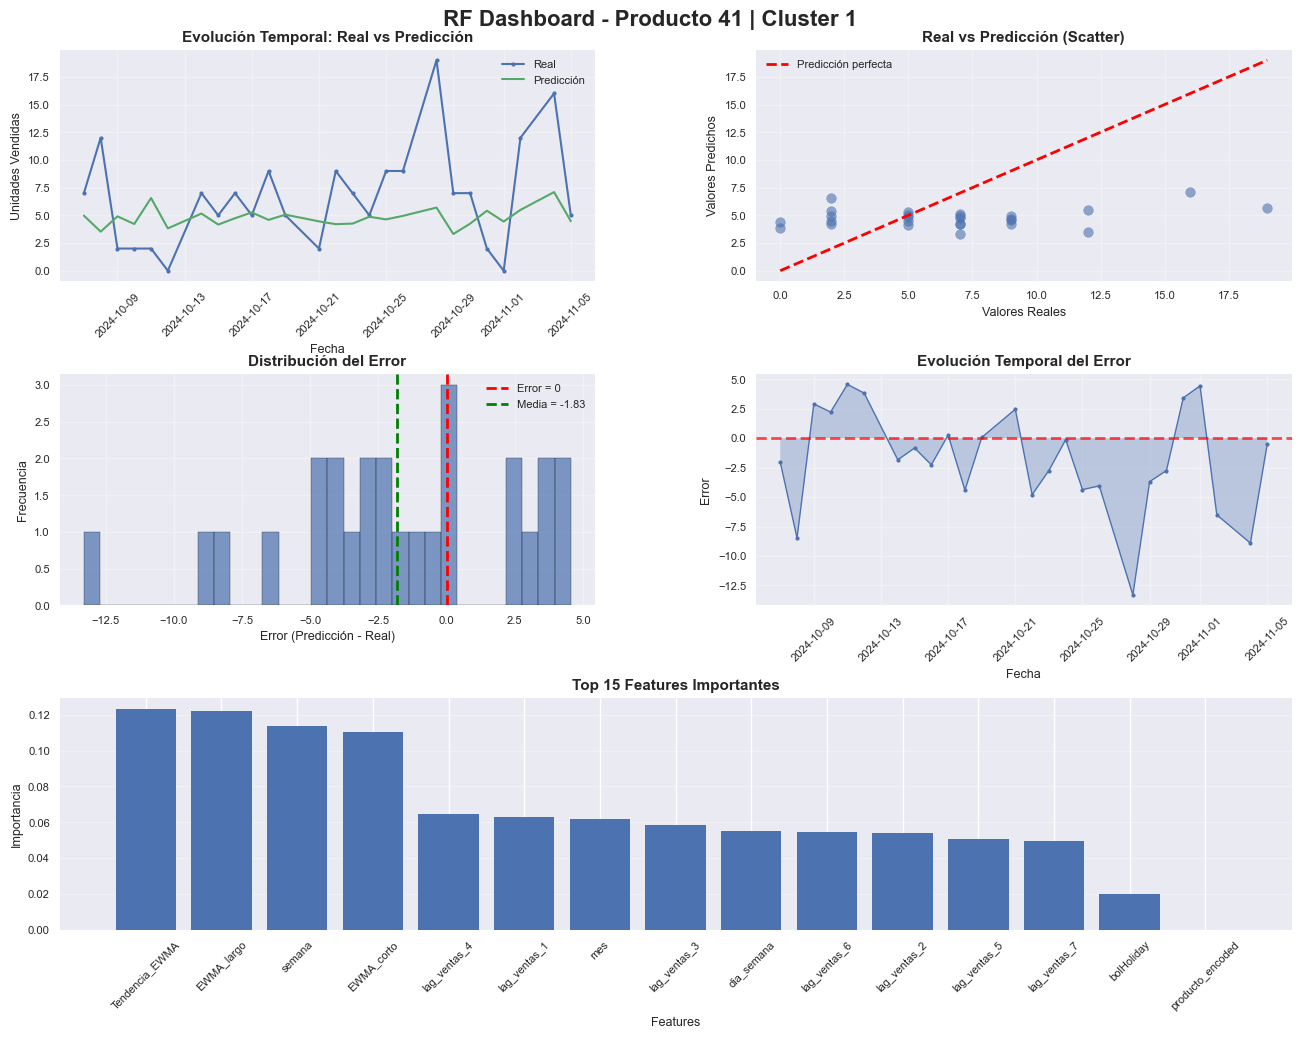


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        2         1 7.9642 11.3423 -0.0368    114.86       70.4 0.7141    67.45

🏆 Mejor modelo: RF (RMSE: 11.3423)


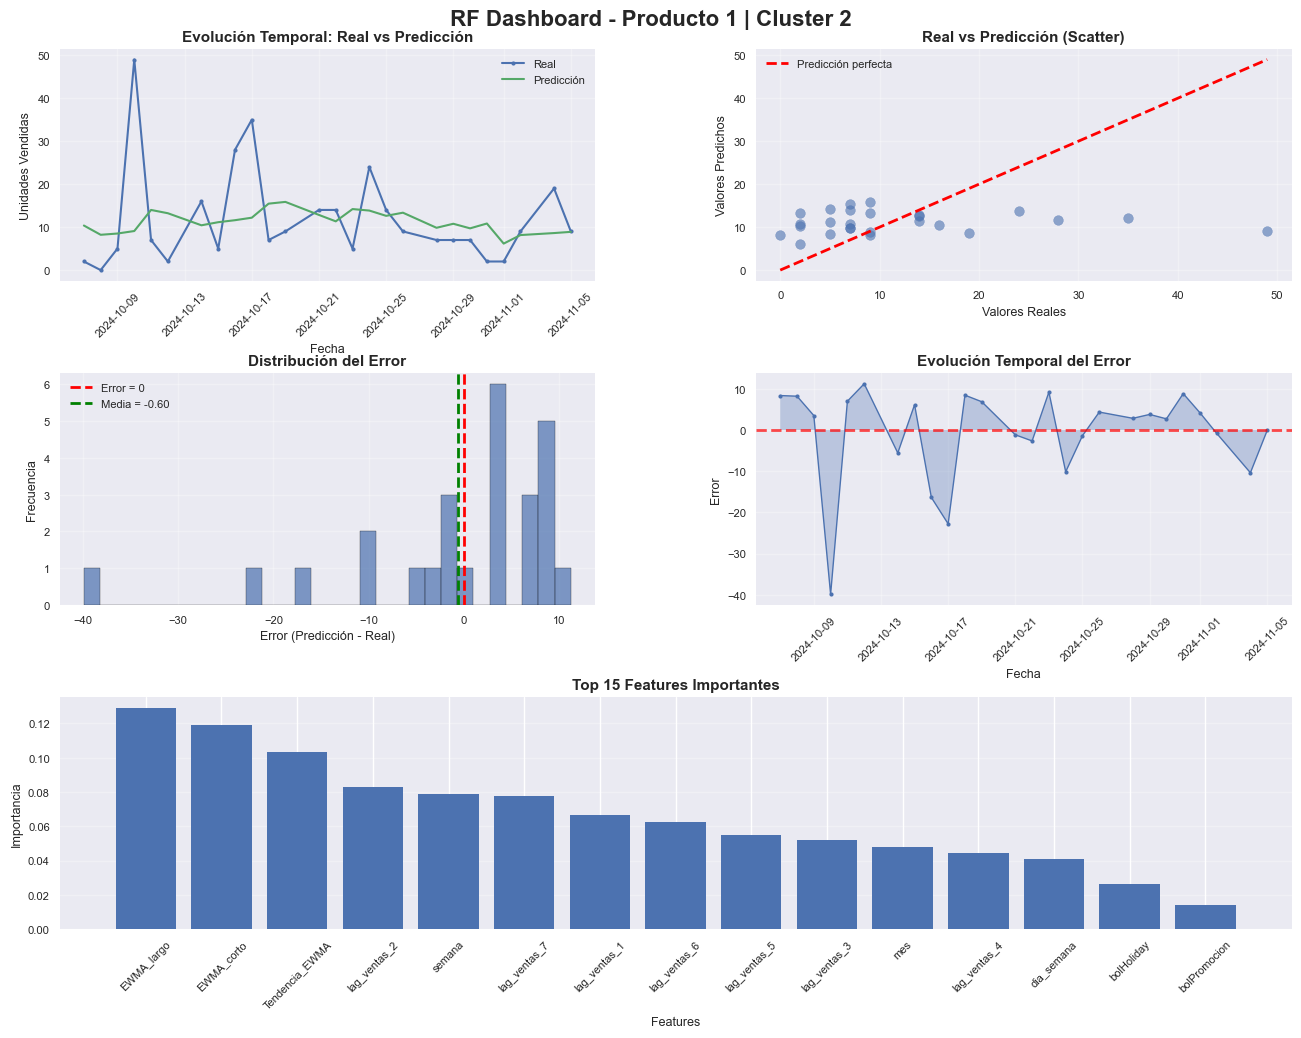


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        2         2 3.9204 4.6997 -0.0804     83.92       68.6  0.653    62.15

🏆 Mejor modelo: RF (RMSE: 4.6997)


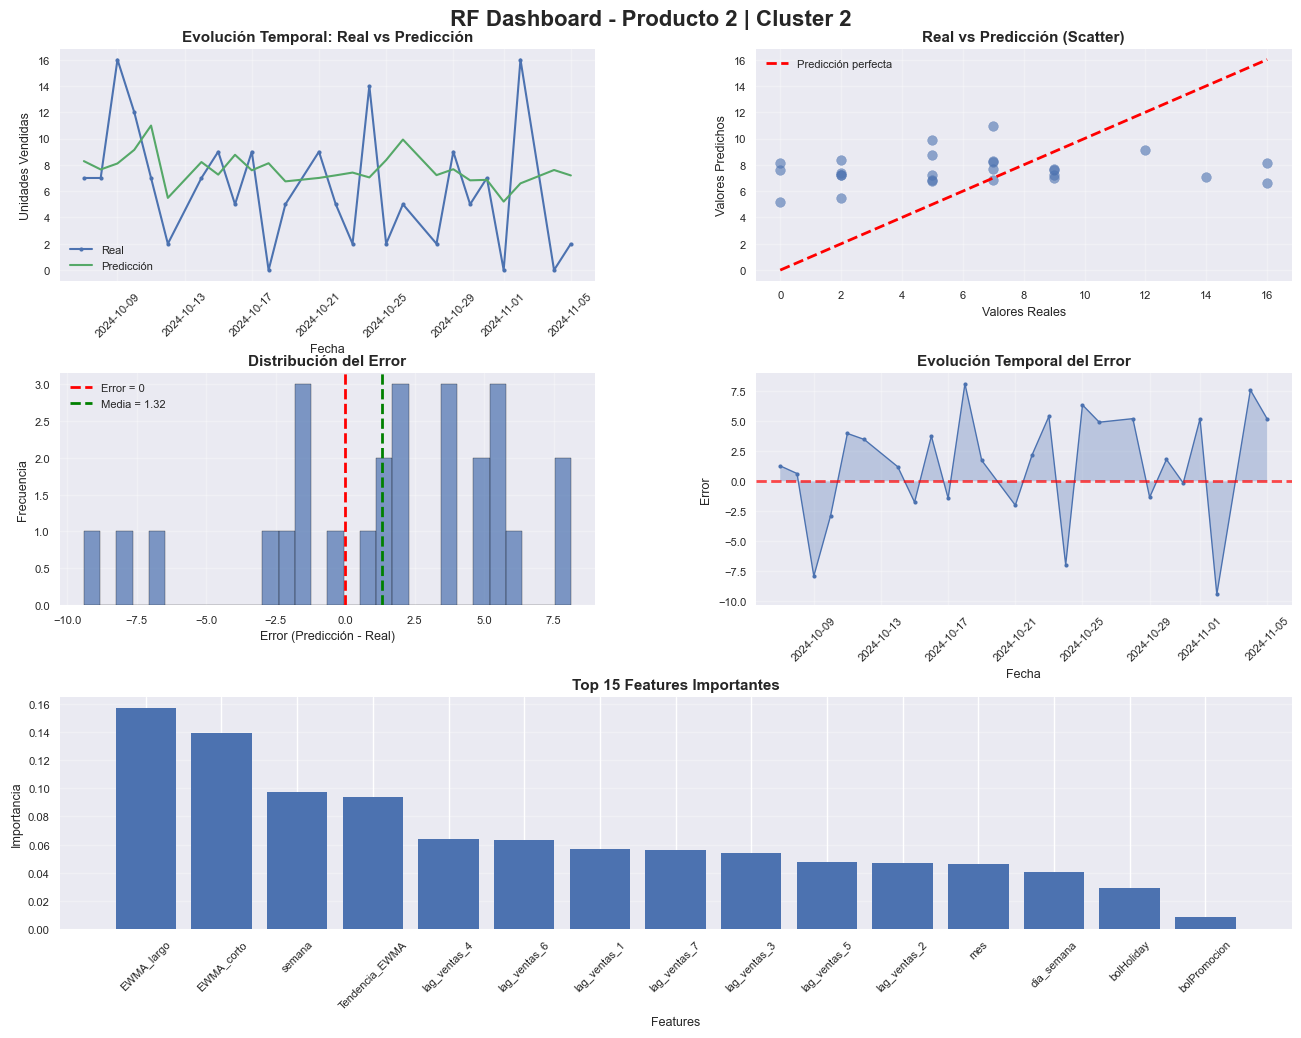


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        3       257 0.9656 1.2981 -0.2699     60.31      180.3 0.8832   193.12

🏆 Mejor modelo: RF (RMSE: 1.2981)


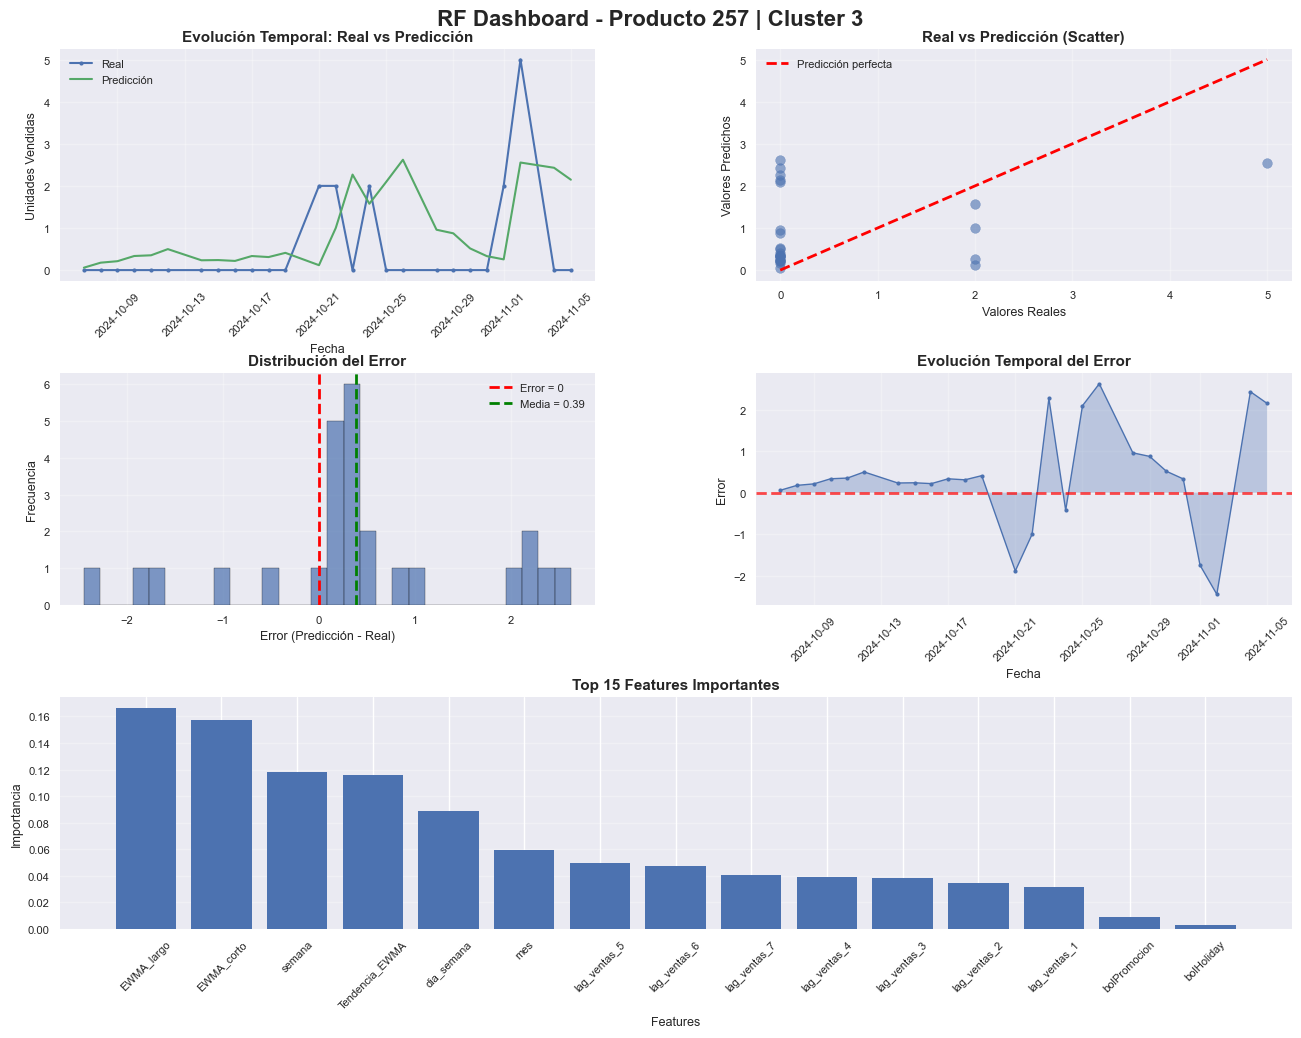


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        3       314 0.7349 0.8126 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: RF (RMSE: 0.8126)


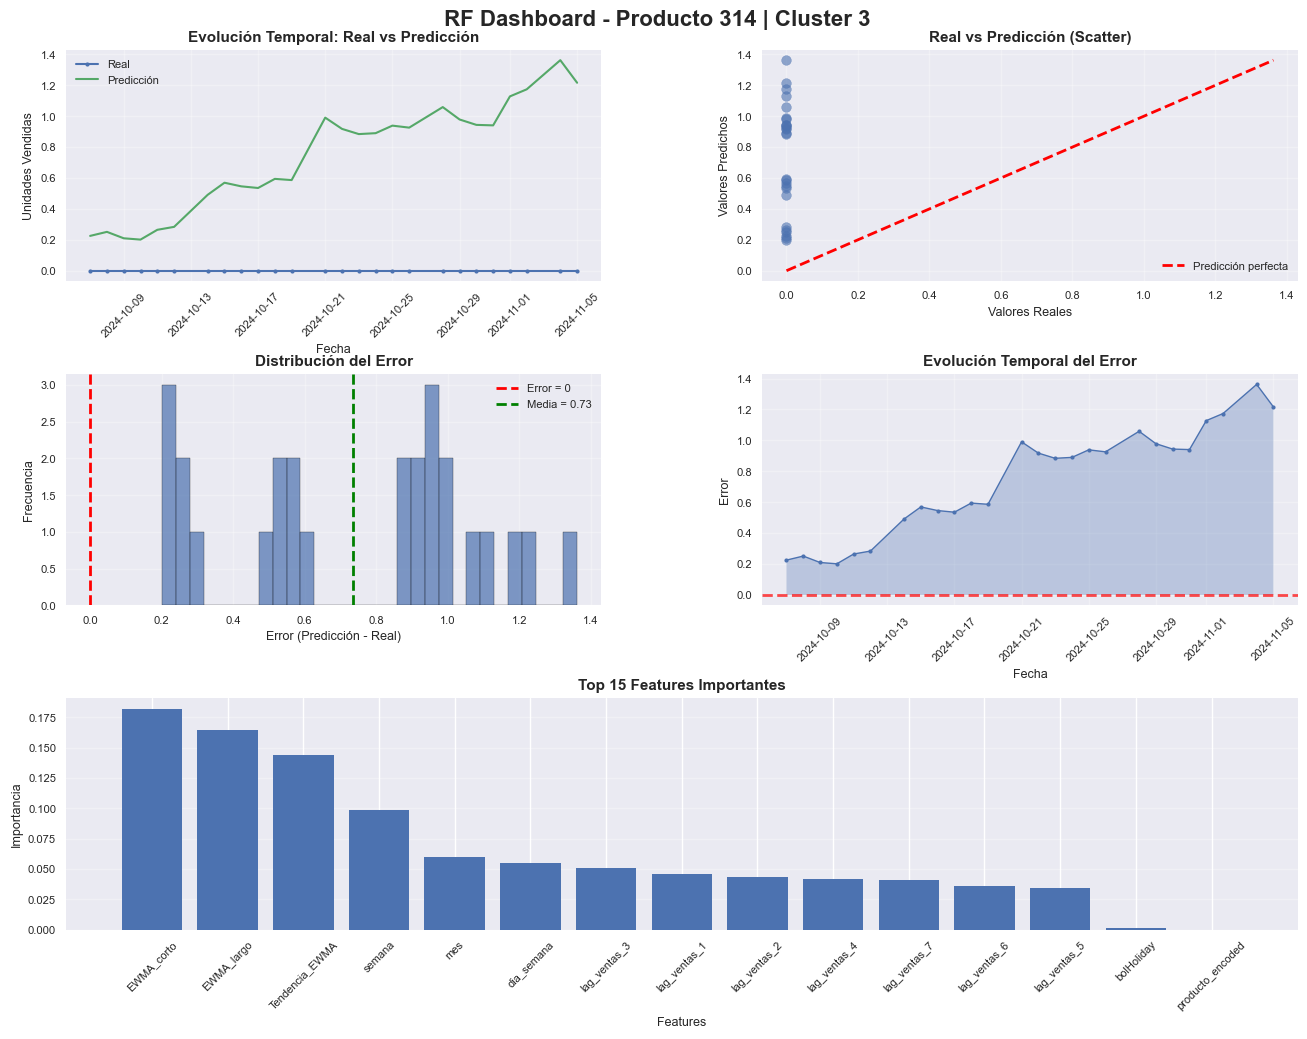


✅ Modelos por producto completados: 8 modelos entrenados


In [13]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: RANDOM FOREST POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        rf_producto = RandomForestRegressor(
            **study_rf.best_params,
            random_state=42,
            n_jobs=-1
        )
        
        rf_producto.fit(X_train_p, y_train_p)
        y_pred_p = rf_producto.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = rf_producto
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(
            y_test_p, y_pred_p,
            algoritmo="RF",
            ndetalle='Producto', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=rf_producto,
            feature_names=FEATURES,
            titulo_principal=f' RF Dashboard - Producto {producto} | Cluster {cluster}'
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final

In [14]:

# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

# Ejecutar el resumen final usando la función de la librería
resumen_final_modelos(todas_metricas)



🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster      3.0     314.0 0.5118   0.2713  0.5209  0.0000       NaN     200.00    NaN      NaN
       RF  Cluster      3.0     257.0 1.0287   1.6058  1.2672 -0.2102     64.19     180.63 0.8622   205.74
       RF  Cluster      3.0       NaN 1.1064   2.9654  1.7220  0.0064     54.03     168.32 0.7727   136.24
       RF  Cluster      0.0     413.0 1.7699   4.6812  2.1636  0.0329     35.70     102.57 0.7574    85.22
       RF  Cluster      0.0       NaN 1.8134   6.5051  2.5505  0.1163     39.26     125.21 0.7332    93.91
       RF  Cluster      0.0     294.0 2.2861   8.6823  2.9466 -0.0885     40.75     130.69 0.6789   123.83
       RF  Cluster      1.0       NaN 2.8143  12.9369  3.5968  0.1395     55.81      98.28 0.7189    73.81
       RF  Cluster      1.0      41.0

# Salvar resultados

In [15]:
# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_rf.csv', index=False)
print("Resultados guardados en 'datos/resultados_metricas_rf.csv'")

Resultados guardados en 'datos/resultados_metricas_rf.csv'
